# Car Dimensions: A Look Through Time

Have cars of the same model grown larger over the years, or does the change in size depend on the specific model?

To explore this question, we have a dataset in the file `car-dimensions.csv`, which presents the `length`, `width`, and `height` (all in millimeters) for 53 car models. This dataset includes measurements from the earliest generation of each model that we could find, as well as data from the latest model. 

By analyzing this information, we can uncover trends and patterns in the evolution of car dimensions over time.

In [143]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'car-dimensions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('car-dimensions.csv')
df.head(4)

,brand_model,length,width,height,year,generation
0,Audi A4,4520,1733,1415,1994,first
1,Audi A4,4762,1847,1427,2015,latest
2,BMW 3 Series,4355,1610,1380,1975,first
3,BMW 3 Series,4829,1827,1442,2018,latest


In [145]:
first_generation = df.query('generation == "first"')
first_generation.head(2)

,brand_model,length,width,height,year,generation
0,Audi A4,4520,1733,1415,1994,first
2,BMW 3 Series,4355,1610,1380,1975,first


In [146]:
latest_generation = df.query('generation == "latest"')
latest_generation.head(2)

,brand_model,length,width,height,year,generation
1,Audi A4,4762,1847,1427,2015,latest
3,BMW 3 Series,4829,1827,1442,2018,latest


In [155]:
# Add equality line
from matplotlib.lines import lineStyles

def add_equality_line():
    x = [0, 12500000000, 25000000000]
    y = [0, 12500000000, 25000000000]
    plt.plot(x, y, color='black', alpha=0.5, linestyle='--')

# Label outliers
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas
- Create paired scatter plots of car `width`, `length`, or `height`.

- Follow the Pro Tips.

- Add labels to datapoints to tell a story.

- Create new variables such as:
	- `car footprint = (length * width)`
	- `percent change = (latest - first) / first`
	
- Create horizontal bar plots showing which car models have changed the least or most for a variable of your choice.

Below is a preliminary paired scatter plot of car `length` to get you started. 

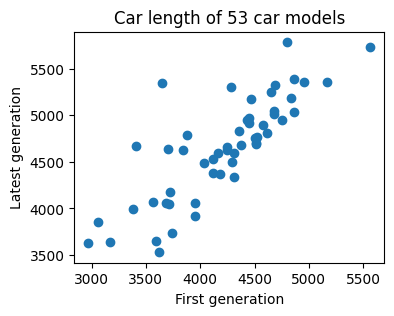

In [148]:
plt.figure(figsize=(4, 3))  
plt.scatter(first_generation['length'], latest_generation['length'])
plt.xlabel('First generation')
plt.ylabel('Latest generation')
plt.title('Car length of 53 car models')
plt.show()

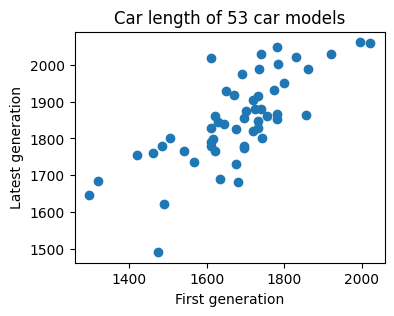

In [149]:
plt.figure(figsize=(4, 3))  
plt.scatter(first_generation['width'], latest_generation['width'])
plt.xlabel('First generation')
plt.ylabel('Latest generation')
plt.title('Car length of 53 car models')
plt.show()

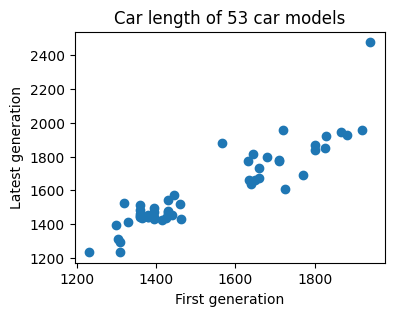

In [150]:
plt.figure(figsize=(4, 3))  
plt.scatter(first_generation['height'], latest_generation['height'])
plt.xlabel('First generation')
plt.ylabel('Latest generation')
plt.title('Car length of 53 car models')
plt.show()

In [151]:
first_generation['first_volume'] = first_generation['length'] * first_generation['width'] * first_generation['height']
latest_generation['latest_volume'] = latest_generation['length'] * latest_generation['width'] * latest_generation['height']
merged_df = pd.merge(first_generation, latest_generation, on='brand_model', how='outer')
volume = merged_df[['brand_model', 'first_volume', 'latest_volume']].copy()
volume['latest_minus_first'] = volume.eval('latest_volume - first_volume')
volume = volume.sort_values(by='latest_minus_first', ascending=False)
volume

biggest_volume_diff = volume.head(5)
biggest_volume_diff 

/var/folders/3l/m5jc265s55bf344jgjb45h8w0000gn/T/ipykernel_34917/219746619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  first_generation['first_volume'] = first_generation['length'] * first_generation['width'] * first_generation['height']
/var/folders/3l/m5jc265s55bf344jgjb45h8w0000gn/T/ipykernel_34917/219746619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest_generation['latest_volume'] = latest_generation['length'] * latest_generation['width'] * latest_generation['height']


,brand_model,first_volume,latest_volume,latest_minus_first
52,Volkswagen Type 2,14281504000,25014767232,10733263232
31,Nissan Patrol,10923720000,21232277500,10308557500
46,Toyota HiLix,11817158500,20222220000,8405061500
30,Mitsubishi Triton,13462680000,18775812000,5313132000
10,Ford F-Series,17694720000,22955099616,5260379616


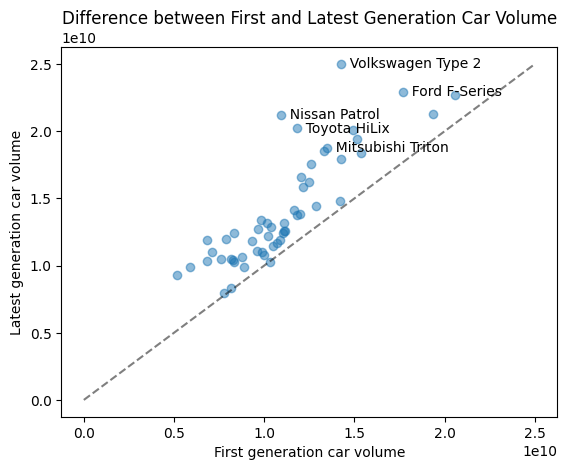

In [156]:
plt.scatter(volume['first_volume'], volume['latest_volume'], alpha=0.5)
plt.xlabel('First generation car volume')
plt.ylabel('Latest generation car volume')
plt.title('Difference between First and Latest Generation Car Volume')
add_equality_line()
add_labels(biggest_volume_diff, 'first_volume', 'latest_volume', 'brand_model')